In [1]:
! git branch

* main


In [2]:
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("./"), os.pardir)))
from customFunctions.utils import *

In [3]:
sequence_alignments_files = os.listdir("data/tRNA_Alignments/")
sequence_alignments_files

['Metazoa_Thr.aln',
 'Metazoa_Pro.aln',
 'Metazoa_Cys.aln',
 'Metazoa_Phe.aln',
 'Metazoa_Val.aln',
 'Metazoa_Ser2.aln',
 'Metazoa_Tyr.aln',
 'Metazoa_Glu.aln',
 'Metazoa_Ala.aln',
 'Metazoa_Asp.aln',
 'Metazoa_Asn.aln',
 'Metazoa_Ile.aln',
 'Metazoa_Ser1.aln',
 'Metazoa_Arg.aln',
 'Metazoa_Met.aln',
 'Metazoa_Gly.aln',
 'Metazoa_His.aln',
 'Metazoa_Leu2.aln',
 'Metazoa_Gln.aln',
 'Metazoa_Lys.aln',
 'Metazoa_Trp.aln',
 'Metazoa_Leu1.aln']

In [4]:
taxa_df = pd.read_csv("data/taxa_Metazoa.txt", sep="\t").set_index("taxid")
taxa_df = taxa_df.loc[:,~taxa_df.columns.str.match("Unnamed:")]
taxa_df["lineage"] = taxa_df.lineage.str.split(" ").str[:-1].apply(lambda x: np.array(x, dtype=int))
blocks = taxa_df.loc[9606, "lineage"]
taxa_df["block"] = taxa_df.lineage.apply(lambda lineage: np.isin(lineage, blocks).sum())
taxa_df["block"] = (taxa_df.block.max()-taxa_df.block)
taxa_df

,code,taxname,lineage,block
taxid,,,,
392897,1,Abalistes stellaris,"[392897, 303702, 31024, 31023, 31022, 1489922,...",18
485912,1,Abispa ephippium,"[485912, 485911, 50638, 7438, 34725, 7434, 740...",25
129035,1,Ablennes hians,"[129035, 129034, 94935, 123731, 76071, 1489913...",18
278977,1,Abronia graminea,"[278977, 76641, 51964, 1329922, 1330543, 8548,...",14
192871,1,Abudefduf vaigiensis,"[192871, 36213, 30863, 1489909, 1489908, 14898...",18
...,...,...,...,...
86543,1,Briareum asbestinum,"[86543, 86542, 86541, 3028851, 6132, 6101, 607...",26
151771,1,Dendronephthya gigantea,"[151771, 51109, 51108, 3028843, 6132, 6101, 60...",26
444732,1,Keratoisidinae sp. BAL208-1,"[444732, 44207, 44204, 3028843, 6132, 6101, 60...",26


In [5]:
taxa_df.groupby("block").taxname.unique()

block
0         [Homo sapiens, Homo sapiens neanderthalensis]
2     [Gorilla gorilla, Gorilla gorilla gorilla, Pan...
3                        [Pongo abelii, Pongo pygmaeus]
4                                       [Hylobates lar]
5     [Chlorocebus aethiops, Chlorocebus pygerythrus...
6                   [Cebus albifrons, Saimiri sciureus]
7            [Cephalopachus bancanus, Carlito syrichta]
8     [Daubentonia madagascariensis, Eulemur fulvus ...
9     [Anomalurus sp. GP-2005, Cavia porcellus, Cric...
10    [Acinonyx jubatus, Ailuropoda melanoleuca, Ail...
11    [Bradypus tridactylus, Choloepus didactylus, C...
12    [Caenolestes fuliginosus, Dactylopsila trivirg...
13    [Ornithorhynchus anatinus, Tachyglossus aculea...
14    [Abronia graminea, Accipiter gentilis, Achalin...
15    [Alytes obstetricans pertinax, Ambystoma ander...
16    [Lepidosiren paradoxa, Neoceratodus forsteri, ...
17         [Latimeria chalumnae, Latimeria menadoensis]
18    [Abalistes stellaris, Ablennes hians

In [6]:
taxa_df.groupby("block").count()

,code,taxname,lineage
block,,,
0,2,2,2
2,4,4,4
3,2,2,2
4,1,1,1
5,15,15,15
6,2,2,2
7,2,2,2
8,13,13,13
9,31,31,31


In [7]:
trna_alignment = pd.concat([
    pd.read_csv("data/tRNA_Alignments/"+file, sep="\t", header=None, index_col=0, names=["sequence"])
    for file in sequence_alignments_files
])
trna_alignment["aa"] = trna_alignment.index.str.split("_").str[-2]
trna_alignment["taxa"] = trna_alignment.index.str.split("_").str[-3].astype(int)
trna_alignment.index = trna_alignment.index.str.split("_").str[0]
trna_alignment = trna_alignment.merge(taxa_df.block, how="left", left_on="taxa", right_index=True)
trna_alignment.sort_values(["aa", "block"], inplace=True)

valid_taxa = (trna_alignment.groupby("taxa").aa.nunique()==22).replace(False, np.nan).dropna().index
trna_alignment = trna_alignment.loc[trna_alignment.taxa.isin(valid_taxa)]

trna_alignment

,sequence,aa,taxa,block
mtdbD00000534,AAGGGCTTAGCTTAATTA--------AAGTGGCTGATTTGCGTTCA...,Ala,9606,0
mtdbD00000468,AAGGGCTTAGCTTAATTA--------AAGTGGCTGATTTGCGTTCA...,Ala,63221,0
mtdbD00000556,AAGGGCTTAGCTTAATTA--------AAGTGGCTGATTTGCGTTCA...,Ala,9593,2
mtdbD00005925,AAGGGCTTAGCTTAATTA--------AAGTGGCTGATTTGCGTTCA...,Ala,9595,2
mtdbD00002794,AAGGGCTTAGCTTAATTA--------AAGTGGCTGATTTGCGTTCA...,Ala,9597,2
...,...,...,...,...
mtdbD00012945,AGGTGTTTA-ACTCAGTGGTA---GAGTG-TTGTGTTTACACCACA...,Val,386100,27
mtdbD00022048,AAGTCCTTA-TCTCAACGGTA---GAGAG-CTGTGTTTACACCACA...,Val,479640,27
mtdbD00007137,TGGTGTTTA-ACTCAGTTGGTA--GAGTG-TTGTATTTACGCTACG...,Val,55567,27
mtdbD00027930,TAGTATTTA-GTTTAATGGGA---AAACT-TTGTGTTTACACCACA...,Val,233783,27


In [8]:
trna_alignment.groupby("aa").taxa.nunique()

aa
Ala     1348
Arg     1348
Asn     1348
Asp     1348
Cys     1348
Gln     1348
Glu     1348
Gly     1348
His     1348
Ile     1348
Leu1    1348
Leu2    1348
Lys     1348
Met     1348
Phe     1348
Pro     1348
Ser1    1348
Ser2    1348
Thr     1348
Trp     1348
Tyr     1348
Val     1348
Name: taxa, dtype: int64

In [9]:
def get_PWM(aa, epsilon=10e-15):
    
    nucleotides = np.array(list('ACGT'))
    
    MSA = np.array(list(trna_alignment.loc[trna_alignment.aa==aa, "sequence"].apply(list)))
    PFM = (MSA[:,:,None]==nucleotides).sum(0).T
    PPM = PFM/PFM.sum(0)
    PPM[PPM==0] = epsilon
    PWM = np.log2(PPM/.25)
    
    PWM = pd.DataFrame(PWM, index=nucleotides).T.stack().to_frame().reset_index()
    PWM.columns = ["alignment_position", "alt", "score"]
    PWM["aa"] = aa
    PWM = PWM.set_index(["aa", "alignment_position", "alt"]).score

    return PWM

get_PWM("Ala")

/tmp/ipykernel_977396/2749029282.py:7: RuntimeWarning: invalid value encountered in divide
  PPM = PFM/PFM.sum(0)


aa   alignment_position  alt
Ala  0                   A      1.545910
                         C     -8.396605
                         G      0.038023
                         T     -4.309142
     1                   A      1.634062
                                  ...   
     80                  T      1.881753
     81                  A      1.916112
                         C     -4.770389
                         G     -2.929086
                         T     -4.107424
Name: score, Length: 328, dtype: float64

In [10]:
PWM_score = pd.concat([get_PWM(aa) for aa in trna_alignment.aa.unique()])
PWM_score

/tmp/ipykernel_977396/2749029282.py:7: RuntimeWarning: invalid value encountered in divide
  PPM = PFM/PFM.sum(0)
/tmp/ipykernel_977396/2749029282.py:7: RuntimeWarning: invalid value encountered in divide
  PPM = PFM/PFM.sum(0)
/tmp/ipykernel_977396/2749029282.py:7: RuntimeWarning: invalid value encountered in divide
  PPM = PFM/PFM.sum(0)
/tmp/ipykernel_977396/2749029282.py:7: RuntimeWarning: invalid value encountered in divide
  PPM = PFM/PFM.sum(0)
/tmp/ipykernel_977396/2749029282.py:7: RuntimeWarning: invalid value encountered in divide
  PPM = PFM/PFM.sum(0)
/tmp/ipykernel_977396/2749029282.py:7: RuntimeWarning: invalid value encountered in divide
  PPM = PFM/PFM.sum(0)
/tmp/ipykernel_977396/2749029282.py:7: RuntimeWarning: invalid value encountered in divide
  PPM = PFM/PFM.sum(0)
/tmp/ipykernel_977396/2749029282.py:7: RuntimeWarning: invalid value encountered in divide
  PPM = PFM/PFM.sum(0)
/tmp/ipykernel_977396/2749029282.py:7: RuntimeWarning: invalid value encountered in divi

aa   alignment_position  alt
Ala  0                   A       1.545910
                         C      -8.396605
                         G       0.038023
                         T      -4.309142
     1                   A       1.634062
                                  ...    
Val  84                  T      -3.265180
     85                  A       2.000000
                         C     -44.506993
                         G     -44.506993
                         T     -44.506993
Name: score, Length: 8056, dtype: float64

In [11]:
def sequence_features(aa, human_position, ref_nt, alt_nt, debug=False):
    
    if ref_nt == alt_nt:
        raise AssertionError("reference nt is equal to alterated nt!")
    
    human_alignment = trna_alignment.loc[
        (trna_alignment.taxa==9606)&(trna_alignment.aa==aa),
        "sequence"
    ][0]
    human_alignment = np.array(list(human_alignment))
    human_positions = np.zeros(len(human_alignment))*np.nan
    human_positions[human_alignment!="-"] = np.arange((human_alignment!="-").sum())
    alignment_position = np.argwhere(human_positions==human_position).ravel()[0]
    if human_alignment[alignment_position] != ref_nt:
        raise AssertionError(
            "given reference nucleotide is `%s` instead of `%s`!"%(
                ref_nt, human_alignment[alignment_position]
            )
        )
    del human_alignment, human_positions
    
    sequence_n_block = trna_alignment.loc[trna_alignment.aa==aa,["sequence", "block"]]
    nt_series, blocks = sequence_n_block.sequence.str[alignment_position], sequence_n_block.block
    del sequence_n_block

    pwm_score = PWM_score.loc[(aa, alignment_position, alt_nt)]
    
    freq_alt_nt = (nt_series[nt_series!="-"]==alt_nt).mean()
    freq_ref_nt = (nt_series[nt_series!="-"]==ref_nt).mean()
    coverage = (nt_series!="-").mean()
    
    nts = np.array(list("ATGC"))
    epsilon = 10e-16
    
    p = (nt_series.values[None,:]==nts[:,None]).mean(1)
    entropy = -(p*np.log2(p+epsilon)).sum()

    blocks = trna_alignment.loc[trna_alignment.aa==aa,"block"]
    conservation = (nt_series==ref_nt).groupby(blocks).all()
    conservation = conservation[~conservation].index.min()
    if np.isnan(conservation):
        conservation = blocks.max()
    
    
    return pd.Series(
        [freq_ref_nt, freq_alt_nt, coverage, entropy, conservation, pwm_score],
        index=["ref_frequency", "alt_frequency", "coverage", "entropy", "conservation_blocks", "PWM_score"]
    )

sequence_features("Val", 10, "C", "A")

/tmp/ipykernel_977396/1392571054.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  human_alignment = trna_alignment.loc[


ref_frequency           0.915430
alt_frequency           0.000742
coverage                0.998519
entropy                 0.425721
conservation_blocks    14.000000
PWM_score              -8.396605
dtype: float64

In [12]:
mithril_df = pd.read_csv(
    "data/mithril_V03.txt",
    sep="\t", low_memory=False, index_col="Mithril_id", na_values="."
).join(
    (~pd.read_csv("data/PTM_and_domains.txt", sep="\t", index_col=0).modification.isna())\
        .groupby(axis=0, level=0).any()
)
mithril_df = mithril_df.loc[mithril_df["class"]=="tRNA"]
mithril_df = mithril_df.loc[:,~(mithril_df.isna().all())]
mithril_df["aa"] =\
    mithril_df["extended.annotation"].str.split("-").str[-1].str.split(" ").str[0].str.strip()\
    + mithril_df["extended.annotation"].str.split(")", expand=True)[1].str.strip()

# following step is made in order to replicate the mtdb nomenclature:
# - invert Leu1 with Leu2
# - invert Ser1 with Ser2
mithril_df["aa"] = mithril_df.aa.str.replace("2","0").str.replace("1","2").str.replace("0","1")
mithril_df["gene.position"] = mithril_df["gene.position"].astype(int)

mithril_df.drop(['MITHRIL.17488', 'MITHRIL.17489', 'MITHRIL.17490'], axis=0, inplace=True)

mithril_df

,Start,Ref,Alt,class,Gene_symbol,extended.annotation,gene.position,gene.start,gene.end,gene.strand,PhastCons_100V,PhyloP_100V,MLC_score,modification,aa
Mithril_id,,,,,,,,,,,,,,,
MITHRIL.1728,577,G,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,1.000,3.724,0.117871,False,Phe
MITHRIL.1729,577,G,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,1.000,3.724,0.117871,False,Phe
MITHRIL.1730,577,G,T,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,1.000,3.724,0.117871,False,Phe
MITHRIL.1731,578,T,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,0.989,1.697,0.128976,False,Phe
MITHRIL.1732,578,T,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,0.989,1.697,0.128976,False,Phe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,1.000,3.604,0.738729,False,Pro
MITHRIL.48240,16022,T,G,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,1.000,3.604,0.738729,False,Pro
MITHRIL.48241,16023,G,A,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),1,15956,16023,-,1.000,5.938,0.734021,False,Pro


In [13]:
complement = {
    "A":"T",
    "T":"A",
    "G":"C",
    "C":"G",
}

ERRORS = []

def sequence_features_wrapper(variant_row, debug=False):
    global ERRORS
    aa, pos = variant_row["aa"], variant_row["gene.position"]-1,
    if variant_row["gene.strand"] == "+":
        ref, alt = variant_row["Ref"], variant_row["Alt"]
    else:
        ref, alt = complement[variant_row["Ref"]], complement[variant_row["Alt"]]
    try :
        return sequence_features(aa, pos, ref, alt, debug)
    except:
        ERRORS.append(variant_row.name)
        return None

In [14]:
sequence_features_result = mithril_df.apply(
    sequence_features_wrapper, axis=1
)
sequence_features_result

/tmp/ipykernel_977396/1392571054.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  human_alignment = trna_alignment.loc[
/tmp/ipykernel_977396/1392571054.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  human_alignment = trna_alignment.loc[
/tmp/ipykernel_977396/1392571054.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  human_alignment = trna_alignment.loc[
/tmp/ipykernel_977396/1392571054.py:6: FutureWarning: Series.__geti

,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score
Mithril_id,,,,,,
MITHRIL.1728,0.832225,0.143385,1.0,0.769628,14.0,-0.802033
MITHRIL.1729,0.832225,0.004435,1.0,0.769628,14.0,-5.816984
MITHRIL.1730,0.832225,0.019956,1.0,0.769628,14.0,-3.647059
MITHRIL.1731,0.509978,0.005174,1.0,1.096296,10.0,-5.594591
MITHRIL.1732,0.509978,0.477458,1.0,1.096296,10.0,0.933444
...,...,...,...,...,...,...
MITHRIL.48239,0.956554,0.023564,1.0,0.316291,14.0,-3.407268
MITHRIL.48240,0.956554,0.004418,1.0,0.316291,14.0,-5.822305
MITHRIL.48241,0.981591,0.012518,1.0,0.154686,14.0,-4.319805


In [15]:
# hairpin_stem instad if hairpin
trna_motif_dict = {
    'Acceptor stem': "stem",
    'D-stem': "hairpin",
    'T-stem': "hairpin",
    'Anticodon stem': "hairpin",
    'D-loop': "loop",
    'T-loop': "loop",
    'Anticodon loop': "loop",
    'Variable region': "bulge",
    np.nan: "bulge"
}
trna_motif_dict

{'Acceptor stem': 'stem',
 'D-stem': 'hairpin',
 'T-stem': 'hairpin',
 'Anticodon stem': 'hairpin',
 'D-loop': 'loop',
 'T-loop': 'loop',
 'Anticodon loop': 'loop',
 'Variable region': 'bulge',
 nan: 'bulge'}

In [16]:
# we have to extract: bulge, stem, hairpin, loop
trna_motifs = pd.read_csv("data/PTM_and_domains.txt", sep="\t", index_col=0)[["domain"]]#.join(mithril_df.aa)
trna_motifs["domain"] = trna_motifs.domain.apply(lambda motif: trna_motif_dict[motif])
trna_motifs = pd.DataFrame(
    trna_motifs.domain.values[:,None] == np.array(["bulge", "stem", "hairpin", "loop"])[None,:],
    columns=["bulge", "stem", "hairpin", "loop"], index=trna_motifs.index
).astype(int)
trna_motifs

,bulge,stem,hairpin,loop
Mithril_id,,,,
MITHRIL.1728,0,1,0,0
MITHRIL.1729,0,1,0,0
MITHRIL.1730,0,1,0,0
MITHRIL.1731,0,1,0,0
MITHRIL.1732,0,1,0,0
...,...,...,...,...
MITHRIL.48239,0,1,0,0
MITHRIL.48240,0,1,0,0
MITHRIL.48241,0,1,0,0


In [17]:
human_trna_motif = pd.read_csv("data/HomoSapiens_mttRNA_Str_simpl.aln", sep="\t", header=None, index_col=0, names=["id", "motif"])
human_trna_motif["aa"] = human_trna_motif.index.str.split("|").str[-2]
human_trna_motif

,motif,aa
id,,
>mtdbD00000534|Homo_sapiens|9606|Ala|TGC,111111100222233333-----22222-22222333333322222...,Ala
>mtdbD00000542|Homo_sapiens|9606|Arg|TCG,111110100222233333-----22220-22222333333322222...,Arg
>mtdbD00000535|Homo_sapiens|9606|Asn|GTT,111111100222333333333--32222-22222333333322222...,Asn
>mtdbD00000539|Homo_sapiens|9606|Asp|GTC,111111100222233333-----22220-22222333333322222...,Asp
>mtdbD00000536|Homo_sapiens|9606|Cys|GCA,1111111002222333-------22220-22222333333322222...,Cys
>mtdbD00000531|Homo_sapiens|9606|Gln|TTG,111111000222233333333--22220-22222333333322222...,Gln
>mtdbD00000546|Homo_sapiens|9606|Glu|TTC,111111100222233333-----22222-22222333333322222...,Glu
>mtdbD00000541|Homo_sapiens|9606|Gly|TCC,111111100222233333-----22220-22222333333322222...,Gly
>mtdbD00000543|Homo_sapiens|9606|His|GTG,111111100222233333-----22220-22222333333322222...,His


In [18]:
human_trna_alignment = pd.read_csv("data/HomoSapiens_mttRNA_Seq.aln", sep="\t", header=None, index_col=0, names=["id", "sequence"])
human_trna_alignment["aa"] = human_trna_alignment.index.str.split("_").str[-2]
human_trna_alignment

,sequence,aa
id,,
mtdbD00000534_Homo_sapie_9606_Ala_TGC,AAGGGCTTAGCTTAATTA-----AAGTG-GCTGATTTGCGTTCAGT...,Ala
mtdbD00000542_Homo_sapie_9606_Arg_TCG,TGGTATATAGTTTAAACA-----AAACG-AATGATTTCGACTCATT...,Arg
mtdbD00000535_Homo_sapie_9606_Asn_GTT,TAGATTGAAGCCAGTTGATTA--GGGTG-CTTAGCTGTTAACTAAG...,Asn
mtdbD00000539_Homo_sapie_9606_Asp_GTC,AAGGTATTAGAAAAACCA-----TTTCA-TAACTTTGTCAAAGTTA...,Asp
mtdbD00000536_Homo_sapie_9606_Cys_GCA,AGCTCCGAGGTGATTT-------TCATA-TTGAATTGCAAATTCGA...,Cys
mtdbD00000531_Homo_sapie_9606_Gln_TTG,TAGGATGGGGTGTGATAGGTG--GCACG-GAGAATTTTGGATTCTC...,Gln
mtdbD00000546_Homo_sapie_9606_Glu_TTC,GTTCTTGTAGTTGAAATA-----CAACG-ATGGTTTTTCATATCAT...,Glu
mtdbD00000541_Homo_sapie_9606_Gly_TCC,ACTCTTTTAGTATAAATA-----GTACC-GTTAACTTCCAATTAAC...,Gly
mtdbD00000543_Homo_sapie_9606_His_GTG,GTAAATATAGTTTAACCA-----AAACA-TCAGATTGTGAATCTGA...,His


In [19]:
def return_alignment_position(aa, position):
    alignment = human_trna_motif.loc[human_trna_motif.aa==aa,"motif"][0]
    alignment = np.array(list(alignment))
    aligned_positions = np.zeros(len(alignment))*np.nan
    aligned_positions[alignment!="-"] = np.arange((alignment!="-").sum())
    alignment_position = np.argwhere(aligned_positions==position).ravel()[0]

    return pd.Series(
        [alignment_position, int(alignment[alignment_position])],
        index = ["Human_MSA_position", "motif"]
    )

return_alignment_position("Tyr", 64)

/tmp/ipykernel_977396/3965802693.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alignment = human_trna_motif.loc[human_trna_motif.aa==aa,"motif"][0]


Human_MSA_position    76
motif                  1
dtype: int64

In [20]:
human_trna_alignment.sequence.apply(len)

id
mtdbD00000534_Homo_sapie_9606_Ala_TGC     81
mtdbD00000542_Homo_sapie_9606_Arg_TCG     81
mtdbD00000535_Homo_sapie_9606_Asn_GTT     81
mtdbD00000539_Homo_sapie_9606_Asp_GTC     81
mtdbD00000536_Homo_sapie_9606_Cys_GCA     81
mtdbD00000531_Homo_sapie_9606_Gln_TTG     81
mtdbD00000546_Homo_sapie_9606_Glu_TTC     81
mtdbD00000541_Homo_sapie_9606_Gly_TCC     81
mtdbD00000543_Homo_sapie_9606_His_GTG     81
mtdbD00000530_Homo_sapie_9606_Ile_GAT     81
mtdbD00000545_Homo_sapie_9606_Leu1_TAG    81
mtdbD00000529_Homo_sapie_9606_Leu2_TAA    81
mtdbD00000540_Homo_sapie_9606_Lys_TTT     81
mtdbD00000532_Homo_sapie_9606_Met_CAT     81
mtdbD00000527_Homo_sapie_9606_Phe_GAA     81
mtdbD00000548_Homo_sapie_9606_Pro_TGG     81
mtdbD00000544_Homo_sapie_9606_Ser1_GCT    81
mtdbD00000538_Homo_sapie_9606_Ser2_TGA    81
mtdbD00000547_Homo_sapie_9606_Thr_TGT     81
mtdbD00000533_Homo_sapie_9606_Trp_TCA     81
mtdbD00000537_Homo_sapie_9606_Tyr_GTA     81
mtdbD00000528_Homo_sapie_9606_Val_TAC     81
Name: s

In [21]:
ERRORS = []

def alignment_position_wrapper(variant_row, debug=False):
    global ERRORS
    aa, pos = variant_row["aa"], variant_row["gene.position"]-1,
    try :
        return return_alignment_position(aa, pos)
    except:
        ERRORS.append(variant_row.name)
        return None

In [22]:
position_features = mithril_df.apply(alignment_position_wrapper, axis=1)

M = np.zeros((len(position_features), position_features.motif.nunique()))
M[np.arange(len(M)), position_features.motif] = 1
position_features[["bulge", "stem", "hairpin", "loop"]] = M.astype(int)

position_features.drop("motif", axis=1, inplace=True)
position_features[trna_motifs.columns] = trna_motifs
position_features

/tmp/ipykernel_977396/3965802693.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alignment = human_trna_motif.loc[human_trna_motif.aa==aa,"motif"][0]


,Human_MSA_position,bulge,stem,hairpin,loop
Mithril_id,,,,,
MITHRIL.1728,0,0,1,0,0
MITHRIL.1729,0,0,1,0,0
MITHRIL.1730,0,0,1,0,0
MITHRIL.1731,1,0,1,0,0
MITHRIL.1732,1,0,1,0,0
...,...,...,...,...,...
MITHRIL.48239,1,0,1,0,0
MITHRIL.48240,1,0,1,0,0
MITHRIL.48241,0,0,1,0,0


In [23]:
sequence_alignments_files = os.listdir("data/tRNA_Alignments_structure/")
sequence_alignments_files

['Metazoa_Thr.aln',
 'Metazoa_Pro.aln',
 'Metazoa_Cys.aln',
 'Metazoa_Phe.aln',
 'Metazoa_Val.aln',
 'Metazoa_Ser2.aln',
 'Metazoa_Tyr.aln',
 'Metazoa_Glu.aln',
 'Metazoa_Ala.aln',
 'Metazoa_Asp.aln',
 'Metazoa_Asn.aln',
 'Metazoa_Ile.aln',
 'Metazoa_Ser1.aln',
 'Metazoa_Arg.aln',
 'Metazoa_Met.aln',
 'Metazoa_Gly.aln',
 'Metazoa_His.aln',
 'Metazoa_Leu2.aln',
 'Metazoa_Gln.aln',
 'Metazoa_Lys.aln',
 'Metazoa_Trp.aln',
 'Metazoa_Leu1.aln']

In [24]:
trna_structural_alignment = pd.concat([
    pd.read_csv("data/tRNA_Alignments_structure/"+file, sep="\t", header=None, index_col=0, names=["structure"])
    for file in sequence_alignments_files
])

trna_structural_alignment["aa"] = trna_structural_alignment.index.str.split("_").str[-2]
trna_structural_alignment["taxa"] = trna_structural_alignment.index.str.split("_").str[-3]
trna_structural_alignment.index = trna_structural_alignment.index.str.split("_").str[0]
trna_structural_alignment

,structure,aa,taxa
mtdbD00010466,(((.(((..-((((......--------)))).-(((((..........,Thr,392897
mtdbD00017452,(((((((..-((((.......-------)))).-(((((..........,Thr,485912
mtdbD00015757,(((.(((..-((((......--------)))).-(((((..........,Thr,129035
mtdbD00015469,((.((((..-((((.......-------)))).-.((((..........,Thr,278977
mtdbD00024129,(((.(((..-((((.......-------)))).-(((((..........,Thr,192871
...,...,...,...
mtdbD00002104,---(((((((..-((((.......---------)))).-(((((-....,Leu1,9704
mtdbD00028297,---(((((((..-((((........--------)))).-(((((-....,Leu1,75044
mtdbD00029928,---(((.(((..-((((........--------)))).-(((((-....,Leu1,175439
mtdbD00011681,---(((((((..-((((........--------)))).-(((((-....,Leu1,64108


In [25]:
def structural_features(aa, human_position):     
    human_alignment = trna_structural_alignment.loc[
        (trna_structural_alignment.taxa=="9606")&(trna_structural_alignment.aa==aa),
        "structure"
    ][0]
    human_alignment = np.array(list(human_alignment))
    
    human_positions = np.zeros(len(human_alignment))*np.nan
    human_positions[human_alignment!="-"] = np.arange((human_alignment!="-").sum())
    alignment_position = np.argwhere(human_positions==human_position).ravel()[0]
    
    del human_alignment, human_positions
    
    str_series = trna_structural_alignment.loc[trna_structural_alignment.aa==aa,"structure"].str[alignment_position]
    
   
    freq = (str_series[str_series!="-"]=='.').mean()
    
    return freq

structural_features("Gly", 0)

/tmp/ipykernel_977396/1589327192.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  human_alignment = trna_structural_alignment.loc[


np.float64(0.005809731299927378)

In [26]:
ERRORS = []

def structural_features_wrapper(variant_row, debug=False):
    global ERRORS
    aa, pos = variant_row["aa"], variant_row["gene.position"]-1,
    try :
        return structural_features(aa, pos)
    except:
        ERRORS.append(variant_row.name)
        return None

In [27]:
unpaired_frequency = mithril_df.apply(
    structural_features_wrapper, axis=1
).rename("unpaired_frequency")
unpaired_frequency

/tmp/ipykernel_977396/1589327192.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  human_alignment = trna_structural_alignment.loc[


Mithril_id
MITHRIL.1728     0.011603
MITHRIL.1729     0.011603
MITHRIL.1730     0.011603
MITHRIL.1731     0.014503
MITHRIL.1732     0.014503
                   ...   
MITHRIL.48239    0.009386
MITHRIL.48240    0.009386
MITHRIL.48241    0.003610
MITHRIL.48242    0.003610
MITHRIL.48243    0.003610
Name: unpaired_frequency, Length: 4521, dtype: float64

In [28]:
energy_df = [
    trna.split("\n")
    for trna in open("data/Mito_tRNA_variants_folded.txt").read().split("\n>")[1:]
]
energy_df = [
    [*trna[:2], *trna[2].split(" ", maxsplit=1)]
    for trna in energy_df
]
energy_df = pd.DataFrame(energy_df, columns=["aa_or_id", "seq", "ss", "ss_energy"]).set_index("aa_or_id")
energy_df["ss_energy"] = energy_df.ss_energy.str.replace("[\(\)]", "", regex=True).astype(float)
energy_df

<>:10: SyntaxWarning: invalid escape sequence '\('
<>:10: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_977396/1657168273.py:10: SyntaxWarning: invalid escape sequence '\('
  energy_df["ss_energy"] = energy_df.ss_energy.str.replace("[\(\)]", "", regex=True).astype(float)


,seq,ss,ss_energy
aa_or_id,,,
Ala,AAGGGCUUAGCUUAAUUAAAGUGGCUGAUUUGCGUUCAGUUGAUGC...,(((((((..((((.....)))).(((((.......)))))....((...,-15.2
Arg,UGGUAUAUAGUUUAAACAAAACGAAUGAUUUCGACUCAUUAAAUUA...,(((((.(..((((.....)))).(((((.......)))))....((...,-5.0
Asn,UAGAUUGAAGCCAGUUGAUuAGGGUGCUUAGCUGUUAACUAAGUGU...,(((((((..(((..........))).(((((.......)))))......,-11.5
Asp,AAGGUAUUAGAAAAACCAUUUCAUAACUUUGUCAAAGUUAAAUUAU...,(((((((..((((.....)))).(((((.......)))))....((...,-7.3
Cys,AGCUCCGAGGUGAUUUUCAUAUUGAAUUGCAAAUUCGAAGAAGCAG...,(((((((..((((...)))).(((((.......)))))....((((...,-15.0
...,...,...,...
Ser2,GAAAAAGUCAUGGAGGCCAUGGGGUUGGCUUGAAACCAGCUUUGGG...,(((((((((((.......)))).(((((.......)))))....((...,-10.4
Thr,GUCCUUGUAGUAUAAACUAAUACACCAGUCUUGUAAACCGGAGAUG...,(((((((..((((......)))).((.((.......)).))....(...,-11.5
Trp,AGAAAUUUAGGUUAAAUACAGACCAAGAGCCUUCAAAGCCCUCAGU...,(((((((..((((.......)))).((.((.......)).)).......,-7.0


In [29]:
human_trna_alignment = human_trna_alignment.merge(energy_df, left_on="aa", right_index=True)
human_trna_alignment

,sequence,aa,seq,ss,ss_energy
id,,,,,
mtdbD00000534_Homo_sapie_9606_Ala_TGC,AAGGGCTTAGCTTAATTA-----AAGTG-GCTGATTTGCGTTCAGT...,Ala,AAGGGCUUAGCUUAAUUAAAGUGGCUGAUUUGCGUUCAGUUGAUGC...,(((((((..((((.....)))).(((((.......)))))....((...,-15.2
mtdbD00000542_Homo_sapie_9606_Arg_TCG,TGGTATATAGTTTAAACA-----AAACG-AATGATTTCGACTCATT...,Arg,UGGUAUAUAGUUUAAACAAAACGAAUGAUUUCGACUCAUUAAAUUA...,(((((.(..((((.....)))).(((((.......)))))....((...,-5.0
mtdbD00000535_Homo_sapie_9606_Asn_GTT,TAGATTGAAGCCAGTTGATTA--GGGTG-CTTAGCTGTTAACTAAG...,Asn,UAGAUUGAAGCCAGUUGAUuAGGGUGCUUAGCUGUUAACUAAGUGU...,(((((((..(((..........))).(((((.......)))))......,-11.5
mtdbD00000539_Homo_sapie_9606_Asp_GTC,AAGGTATTAGAAAAACCA-----TTTCA-TAACTTTGTCAAAGTTA...,Asp,AAGGUAUUAGAAAAACCAUUUCAUAACUUUGUCAAAGUUAAAUUAU...,(((((((..((((.....)))).(((((.......)))))....((...,-7.3
mtdbD00000536_Homo_sapie_9606_Cys_GCA,AGCTCCGAGGTGATTT-------TCATA-TTGAATTGCAAATTCGA...,Cys,AGCUCCGAGGUGAUUUUCAUAUUGAAUUGCAAAUUCGAAGAAGCAG...,(((((((..((((...)))).(((((.......)))))....((((...,-15.0
mtdbD00000531_Homo_sapie_9606_Gln_TTG,TAGGATGGGGTGTGATAGGTG--GCACG-GAGAATTTTGGATTCTC...,Gln,UAGGAUGGGGUGUGAUAGGUGGCACGGAGAAUUUUGGAUUCUCAGG...,((((((...((((........)))).(((((.......)))))......,-15.4
mtdbD00000546_Homo_sapie_9606_Glu_TTC,GTTCTTGTAGTTGAAATA-----CAACG-ATGGTTTTTCATATCAT...,Glu,GUUCUUGUAGUUGAAAUACAACGAUGGUUUUUCAUAUCAUUGGUCG...,(((((((..((((.....)))).(((((.......)))))....((...,-9.2
mtdbD00000541_Homo_sapie_9606_Gly_TCC,ACTCTTTTAGTATAAATA-----GTACC-GTTAACTTCCAATTAAC...,Gly,ACUCUUUUAGUAUAAAUAGUACCGUUAACUUCCAAUUAACUAGUUU...,(((((((..((((.....)))).(((((.......)))))....((...,-8.4
mtdbD00000543_Homo_sapie_9606_His_GTG,GTAAATATAGTTTAACCA-----AAACA-TCAGATTGTGAATCTGA...,His,GUAAAUAUAGUUUAACCAAAACAUCAGAUUGUGAAUCUGACAACAG...,(((((((..((((.....)))).(((((.......)))))....((...,-6.9


In [30]:
mithril_df = mithril_df.join(energy_df)
mithril_df = mithril_df.merge(
    human_trna_alignment.set_index("aa").ss_energy.rename("wt_ss_energy"),
    left_on="aa", right_index=True
)
mithril_df["ddG"] = mithril_df.ss_energy-mithril_df.wt_ss_energy
mithril_df["normalized_ddG"] = mithril_df.ddG/mithril_df.wt_ss_energy.abs()
mithril_df

,Start,Ref,Alt,class,Gene_symbol,extended.annotation,gene.position,gene.start,gene.end,gene.strand,...,PhyloP_100V,MLC_score,modification,aa,seq,ss,ss_energy,wt_ss_energy,ddG,normalized_ddG
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,577,G,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,3.724,0.117871,False,Phe,AUUUAUGUAGCUUACCUCCUcAAAGCAAUACACUGAAAAUGUUUAG...,.((((((..((((.........)))).(.(((.......))).).....,-3.5,-7.3,3.8,0.520548
MITHRIL.1729,577,G,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,3.724,0.117871,False,Phe,CUUUAUGUAGCUUACCUCCUcAAAGCAAUACACUGAAAAUGUUUAG...,.((((((..((((.........)))).(.(((.......))).).....,-3.6,-7.3,3.7,0.506849
MITHRIL.1730,577,G,T,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,3.724,0.117871,False,Phe,UUUUAUGUAGCUUACCUCCUcAAAGCAAUACACUGAAAAUGUUUAG...,.((((((..((((.........)))).(.(((.......))).).....,-3.6,-7.3,3.7,0.506849
MITHRIL.1731,578,T,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,...,1.697,0.128976,False,Phe,GAUUAUGUAGCUUACCUCCUcAAAGCAAUACACUGAAAAUGUUUAG...,(.(((((..((((.........)))).(.(((.......))).).....,-3.0,-7.3,4.3,0.589041
MITHRIL.1732,578,T,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,...,1.697,0.128976,False,Phe,GCUUAUGUAGCUUACCUCCUcAAAGCAAUACACUGAAAAUGUUUAG...,(.(((((..((((.........)))).(.(((.......))).).....,-3.0,-7.3,4.3,0.589041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,...,3.604,0.738729,False,Pro,CGGAGAAUAGUUUAAAUUAGAAUCUUAGCUUUGGGUGCUAAUGGUG...,(((((((..((((......)))).(((((.......)))))....(...,-9.0,-9.7,0.7,0.072165
MITHRIL.48240,16022,T,G,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,...,3.604,0.738729,False,Pro,CCGAGAAUAGUUUAAAUUAGAAUCUUAGCUUUGGGUGCUAAUGGUG...,(.(((((..((((......)))).(((((.......)))))....(...,-5.0,-9.7,4.7,0.484536
MITHRIL.48241,16023,G,A,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),1,15956,16023,-,...,5.938,0.734021,False,Pro,UAGAGAAUAGUUUAAAUUAGAAUCUUAGCUUUGGGUGCUAAUGGUG...,(((((((..((((......)))).(((((.......)))))....(...,-7.8,-9.7,1.9,0.195876


In [31]:
mithril_df["ss_distorsion"] = pd.concat([
    mithril_df.ss.str.replace("<", ".").str.replace(">", ".").reset_index(drop=True),
    mithril_df.merge(human_trna_alignment, on="aa", suffixes=["", "_wt"], how="left")\
        .ss_wt.str.replace("<", ".").str.replace(">", ".").reset_index(drop=True)
], axis=1).apply(
    lambda variant: 1-(np.array(list(variant.ss)) == np.array(list(variant.ss_wt))).mean(),
    axis=1
).values
mithril_df

,Start,Ref,Alt,class,Gene_symbol,extended.annotation,gene.position,gene.start,gene.end,gene.strand,...,MLC_score,modification,aa,seq,ss,ss_energy,wt_ss_energy,ddG,normalized_ddG,ss_distorsion
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,577,G,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,0.117871,False,Phe,AUUUAUGUAGCUUACCUCCUcAAAGCAAUACACUGAAAAUGUUUAG...,.((((((..((((.........)))).(.(((.......))).).....,-3.5,-7.3,3.8,0.520548,0.028169
MITHRIL.1729,577,G,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,0.117871,False,Phe,CUUUAUGUAGCUUACCUCCUcAAAGCAAUACACUGAAAAUGUUUAG...,.((((((..((((.........)))).(.(((.......))).).....,-3.6,-7.3,3.7,0.506849,0.028169
MITHRIL.1730,577,G,T,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,0.117871,False,Phe,UUUUAUGUAGCUUACCUCCUcAAAGCAAUACACUGAAAAUGUUUAG...,.((((((..((((.........)))).(.(((.......))).).....,-3.6,-7.3,3.7,0.506849,0.028169
MITHRIL.1731,578,T,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,...,0.128976,False,Phe,GAUUAUGUAGCUUACCUCCUcAAAGCAAUACACUGAAAAUGUUUAG...,(.(((((..((((.........)))).(.(((.......))).).....,-3.0,-7.3,4.3,0.589041,0.028169
MITHRIL.1732,578,T,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,...,0.128976,False,Phe,GCUUAUGUAGCUUACCUCCUcAAAGCAAUACACUGAAAAUGUUUAG...,(.(((((..((((.........)))).(.(((.......))).).....,-3.0,-7.3,4.3,0.589041,0.028169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,...,0.738729,False,Pro,CGGAGAAUAGUUUAAAUUAGAAUCUUAGCUUUGGGUGCUAAUGGUG...,(((((((..((((......)))).(((((.......)))))....(...,-9.0,-9.7,0.7,0.072165,0.000000
MITHRIL.48240,16022,T,G,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,...,0.738729,False,Pro,CCGAGAAUAGUUUAAAUUAGAAUCUUAGCUUUGGGUGCUAAUGGUG...,(.(((((..((((......)))).(((((.......)))))....(...,-5.0,-9.7,4.7,0.484536,0.029412
MITHRIL.48241,16023,G,A,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),1,15956,16023,-,...,0.734021,False,Pro,UAGAGAAUAGUUUAAAUUAGAAUCUUAGCUUUGGGUGCUAAUGGUG...,(((((((..((((......)))).(((((.......)))))....(...,-7.8,-9.7,1.9,0.195876,0.000000


In [32]:
# ensure that alt sequencies differ from wt sequencies for just one nt
mithril_df.merge(
    energy_df.seq, left_on="aa", right_index=True,
    suffixes=["", "_wt"]
)[["seq", "seq_wt"]].apply(
    lambda row: len([nt for nt, nt_wt in zip(str.upper(row.seq), str.upper(row.seq_wt)) if nt!=nt_wt]),
    axis=1
).unique()

array([1])

In [33]:
# check if predicted stuctures have different len compared to the wt structure
mithril_df[mithril_df.ss.apply(len).values != human_trna_alignment.reset_index().set_index("aa").loc[mithril_df.aa, "ss"].apply(len).values]

,Start,Ref,Alt,class,Gene_symbol,extended.annotation,gene.position,gene.start,gene.end,gene.strand,...,MLC_score,modification,aa,seq,ss,ss_energy,wt_ss_energy,ddG,normalized_ddG,ss_distorsion
Mithril_id,,,,,,,,,,,,,,,,,,,,,


In [34]:
suzuki = pd.read_csv("data/aligned_position_suzuki.csv", sep="\t", index_col="aa").T
for aa in mithril_df.aa.unique():
    suzuki.loc[~suzuki[aa].isna(), aa] = np.arange((~suzuki[aa].isna()).sum())+1
del aa
suzuki = suzuki.T
suzuki.columns.name="suzuki_pos"
suzuki = suzuki.stack().rename("gene.position").reset_index().set_index(["aa", "gene.position"])
suzuki

suzuki_pos
aa  gene.position           
Ala 1                      1
    2                      2
    3                      3
    4                      4
    5                      5
...                      ...
Tyr 62                    69
    63                    70
    64                    71
    65                    72
    66                    73

[1508 rows x 1 columns]

In [35]:
oeuf = mithril_df.merge(
    suzuki, left_on=["aa", "gene.position"], right_index=True, how="left"
).merge(
    pd.read_csv("data/oeuf_lake_et_al.tsv", sep="\t", index_col="suzuki_pos").Upper_CI.rename("OEUF_score"),
    left_on=["suzuki_pos"], right_index=True, how="left"
).OEUF_score
oeuf[oeuf.isna()] = .47 # median value
oeuf

Mithril_id
MITHRIL.1728     0.470
MITHRIL.1729     0.470
MITHRIL.1730     0.470
MITHRIL.1731     0.358
MITHRIL.1732     0.358
                 ...  
MITHRIL.48239    0.358
MITHRIL.48240    0.358
MITHRIL.48241    0.470
MITHRIL.48242    0.470
MITHRIL.48243    0.470
Name: OEUF_score, Length: 4521, dtype: float64

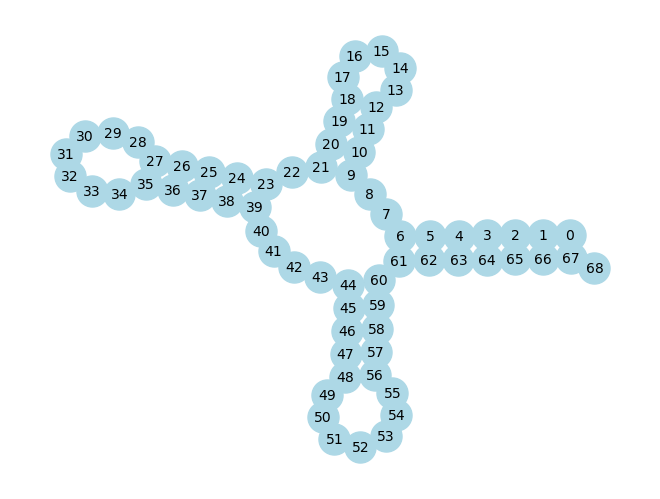

In [36]:
draw_rna_graph(dot_bracket_to_graph(energy_df.loc["Ala", "ss"]))

In [37]:
nt_2d_distances = {
    aa: nx.floyd_warshall_numpy(dot_bracket_to_graph(energy_df.loc[aa, "ss"]))
    for aa in mithril_df.aa.unique()
}
nt_2d_distances

{'Phe': array([[0., 1., 2., ..., 2., 1., 2.],
        [1., 0., 1., ..., 1., 2., 3.],
        [2., 1., 0., ..., 2., 3., 4.],
        ...,
        [2., 1., 2., ..., 0., 1., 2.],
        [1., 2., 3., ..., 1., 0., 1.],
        [2., 3., 4., ..., 2., 1., 0.]]),
 'Val': array([[0., 1., 2., ..., 2., 1., 2.],
        [1., 0., 1., ..., 1., 2., 3.],
        [2., 1., 0., ..., 2., 3., 4.],
        ...,
        [2., 1., 2., ..., 0., 1., 2.],
        [1., 2., 3., ..., 1., 0., 1.],
        [2., 3., 4., ..., 2., 1., 0.]]),
 'Leu2': array([[0., 1., 2., ..., 2., 1., 2.],
        [1., 0., 1., ..., 1., 2., 3.],
        [2., 1., 0., ..., 2., 3., 4.],
        ...,
        [2., 1., 2., ..., 0., 1., 2.],
        [1., 2., 3., ..., 1., 0., 1.],
        [2., 3., 4., ..., 2., 1., 0.]]),
 'Ile': array([[0., 1., 2., ..., 2., 1., 2.],
        [1., 0., 1., ..., 1., 2., 3.],
        [2., 1., 0., ..., 2., 3., 4.],
        ...,
        [2., 1., 2., ..., 0., 1., 2.],
        [1., 2., 3., ..., 1., 0., 1.],
        [2., 3.,

In [38]:
closest_modification_2D = mithril_df[["aa", "gene.position"]].reset_index().merge(
    mithril_df.loc[mithril_df.modification, ["aa", "gene.position"]].drop_duplicates(),
    on="aa", suffixes=["_query", "_modification"]
).set_index("Mithril_id").apply(
    lambda row: nt_2d_distances[row.aa][row["gene.position_query"]-1, row["gene.position_modification"]-1], axis=1
).groupby(axis=0, level=0).min().rename("closest_modification_2D")
closest_modification_2D

Mithril_id
MITHRIL.12787     8.0
MITHRIL.12788     8.0
MITHRIL.12789     8.0
MITHRIL.12790     7.0
MITHRIL.12791     7.0
                 ... 
MITHRIL.9908      9.0
MITHRIL.9909      9.0
MITHRIL.9910     10.0
MITHRIL.9911     10.0
MITHRIL.9912     10.0
Name: closest_modification_2D, Length: 4521, dtype: float64

In [39]:
closest_modification = mithril_df[["aa", "gene.position"]].reset_index().merge(
    mithril_df.loc[mithril_df.modification, ["aa", "gene.position"]].drop_duplicates(),
    on="aa", suffixes=["_query", "_modification"]
).set_index("Mithril_id")
closest_modification["closest_modification"] = (
    closest_modification["gene.position_query"] - closest_modification["gene.position_modification"]
).abs()
closest_modification = closest_modification.groupby(axis=0, level=0).closest_modification.min()
closest_modification

/tmp/ipykernel_977396/4257440024.py:8: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  closest_modification = closest_modification.groupby(axis=0, level=0).closest_modification.min()


Mithril_id
MITHRIL.12787     8
MITHRIL.12788     8
MITHRIL.12789     8
MITHRIL.12790     7
MITHRIL.12791     7
                 ..
MITHRIL.9908     14
MITHRIL.9909     14
MITHRIL.9910     15
MITHRIL.9911     15
MITHRIL.9912     15
Name: closest_modification, Length: 4521, dtype: int64

In [40]:
##################################
############## SAVE ##############
##################################
mithril_df[["PhastCons_100V", "PhyloP_100V", "MLC_score", "ss_distorsion", "ddG"]]\
    .join(sequence_features_result).join(position_features).join(unpaired_frequency)\
        .join(closest_modification).join(closest_modification_2D).join(oeuf)\
            .to_csv("checkpoints/mithril_features.csv", sep="\t")